Logistic Regression:

Picture4.png

Y_hat --> predicted value

X --> Input Variable

w --> weight

b --> bias

Gradient Descent:

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w = w - α*dw

b = b - α*db

Learning Rate:

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

Derivatives:
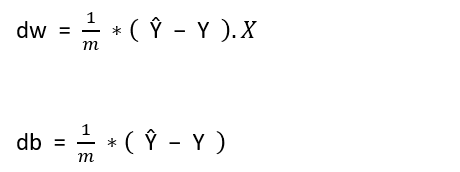

# Importing Required Dependencies

In [233]:
import pandas as pd
import numpy as np

# Logistic Regression

Steps:

- Step 1: Set Learning Rate & Number of Iterations; Initiate Random weight and bias value.

- Step 2: Build Logistic Regression Function. (sigmoid function)

- Step 3: Update the parameters using gradient descent

- Finally we will get the best model (best weight and bias value) as it has minimum cost function.

- step 4: build the "predict" function to determine the class of the data point.

In [234]:
class Logistic_Regression():

    # Initiating the Paramerters (Learning Rate and No of Iteration)

    def __init__(self, learning_rate, no_of_iteration):

        self.learning_rate = learning_rate
        self.no_of_iteration = no_of_iteration

    def fit(self, X, Y):

        # No of Training Examples and No of Features

        # number of data points in the dataset (number of rows)  -->  m
        # number of input features in the dataset (number of columns)  --> n

        self.m, self.n = X.shape    

        #Initiating The Weights and Bias

        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

        # Implementing Gradient Descent

        for i in range(self.no_of_iteration):
            self.Update_Weight()


    def Update_Weight(self):

        # Y_hat Formula (Sigmoid Function)

        Z = self.X.dot(self.w) + self.b
        Y_hat =  (1 / (1 + np.exp(-Z)))

        # Derivative

        dw = (1 / self.m) * np.dot(self.X.T, (Y_hat - self.Y))
        db = (1 / self.m) * np.sum(Y_hat - self.Y)

        # Update Weight and Bias Using Gradient Descent

        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    # Sigmoid Equation and Decision Boundary

    def Predict(self, X):
        Z = X.dot(self.w) + self.b
        Y_pred =  (1 / (1 + np.exp(-Z)))
        Y_pred = np.where(Y_pred > 0.5, 1, 0)
        return Y_pred


# Implementing Logistic Regression

### Importing Required Libraries

In [235]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### Data Collection and Analysis

Diabetes Dataset

In [236]:
# Loading the dataset 

diabetes_dataset = pd.read_csv('diabetes.csv')

In [237]:
# Viewing First Five Rows

diabetes_dataset.head(30)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [238]:
# Viewing Last Five Rows

diabetes_dataset.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [239]:
# No of rows and cols

diabetes_dataset.shape

(768, 9)

In [240]:
# Statistical measuers

diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [241]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

- 0 -> Non Diabetic
- 1 -> Diabetic

In [242]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


### Seperating Data and Labels

In [243]:
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

In [244]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [245]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


### Data Standardization

In [246]:
scalar = StandardScaler()

In [247]:
scalar.fit(X)

,copy,True
,with_mean,True
,with_std,True


In [248]:
standardized_data = scalar.transform(X)

In [249]:
print(standardized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [250]:
X = standardized_data
Y = diabetes_dataset['Outcome']

In [251]:
print(X)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [252]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


### Train Test Split

In [253]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=2, test_size=0.2)

In [254]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


### Training Our Model

In [255]:
classifer = Logistic_Regression(learning_rate=0.01, no_of_iteration=1000)

In [256]:
classifer.fit(X_train, Y_train)

### Model Evaluation

Accuracy Score

In [257]:
# Accuracy Score on Training Data

X_train_prediction = classifer.Predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [258]:
print("Accuracy Score on Training Data: ",training_data_accuracy)

Accuracy Score on Training Data:  0.7768729641693811


In [259]:
# Accuracy Score on Test Data

X_test_prediction = classifer.Predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [260]:
print("Accuracy Score on Test Data: ", test_data_accuracy)

Accuracy Score on Test Data:  0.7662337662337663


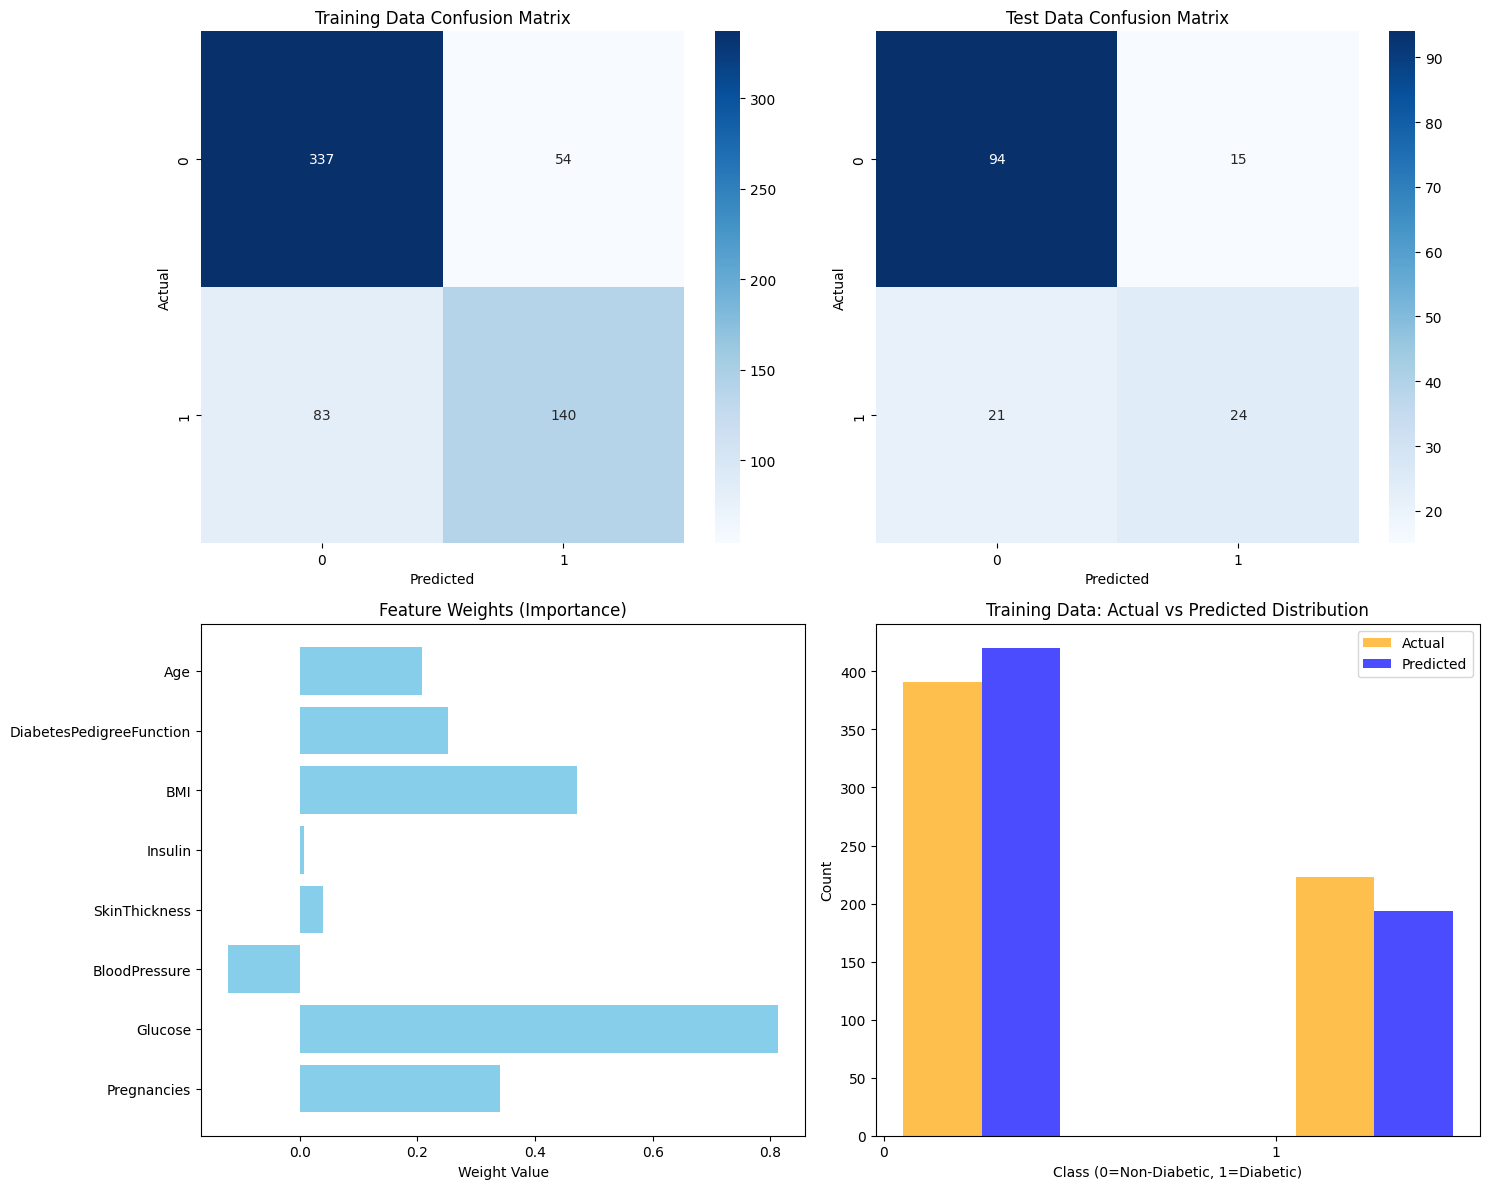

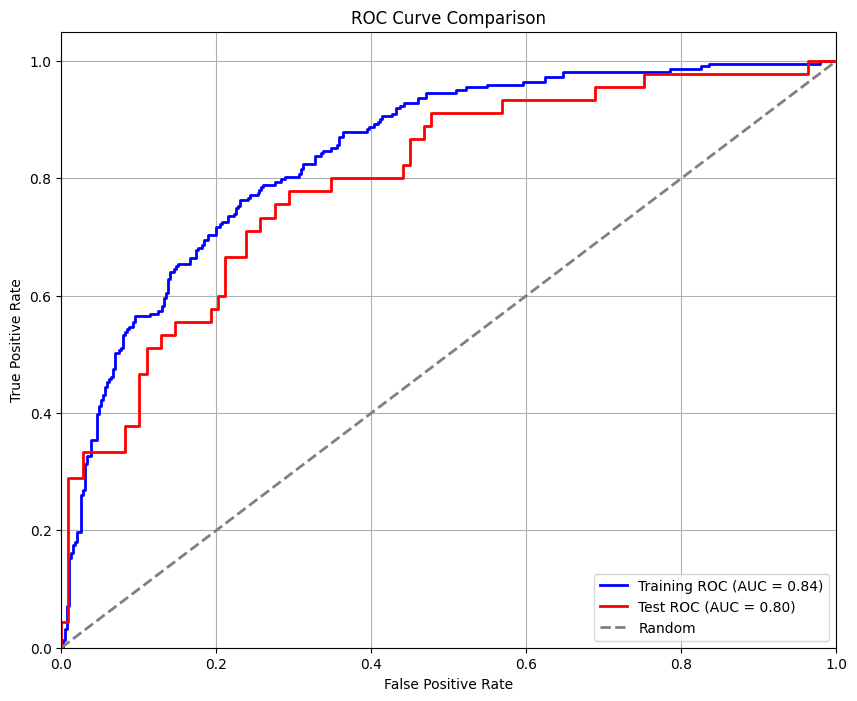

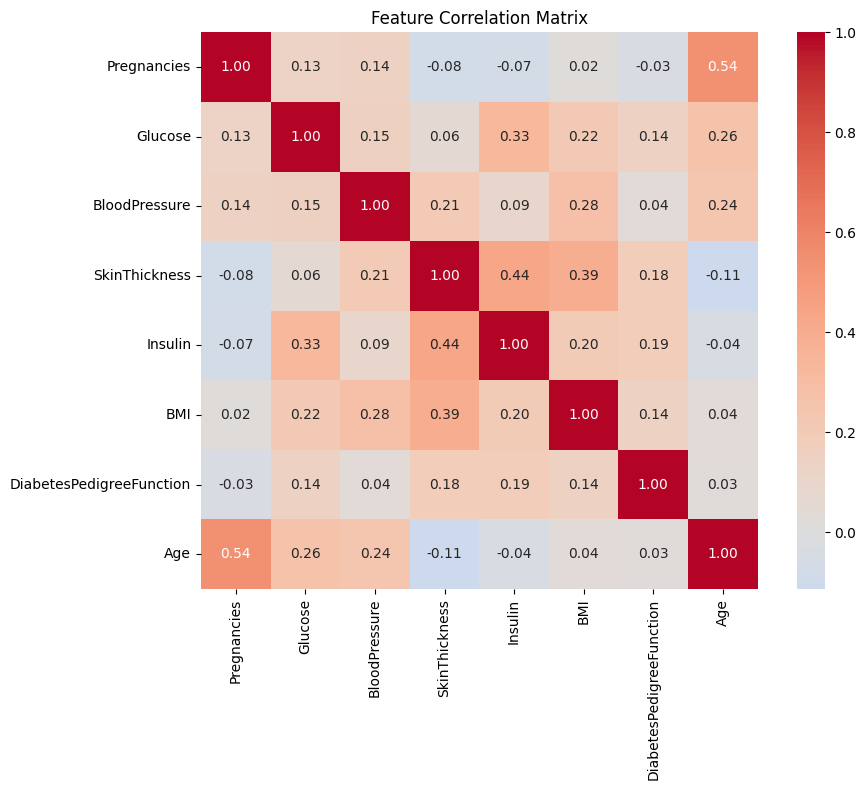

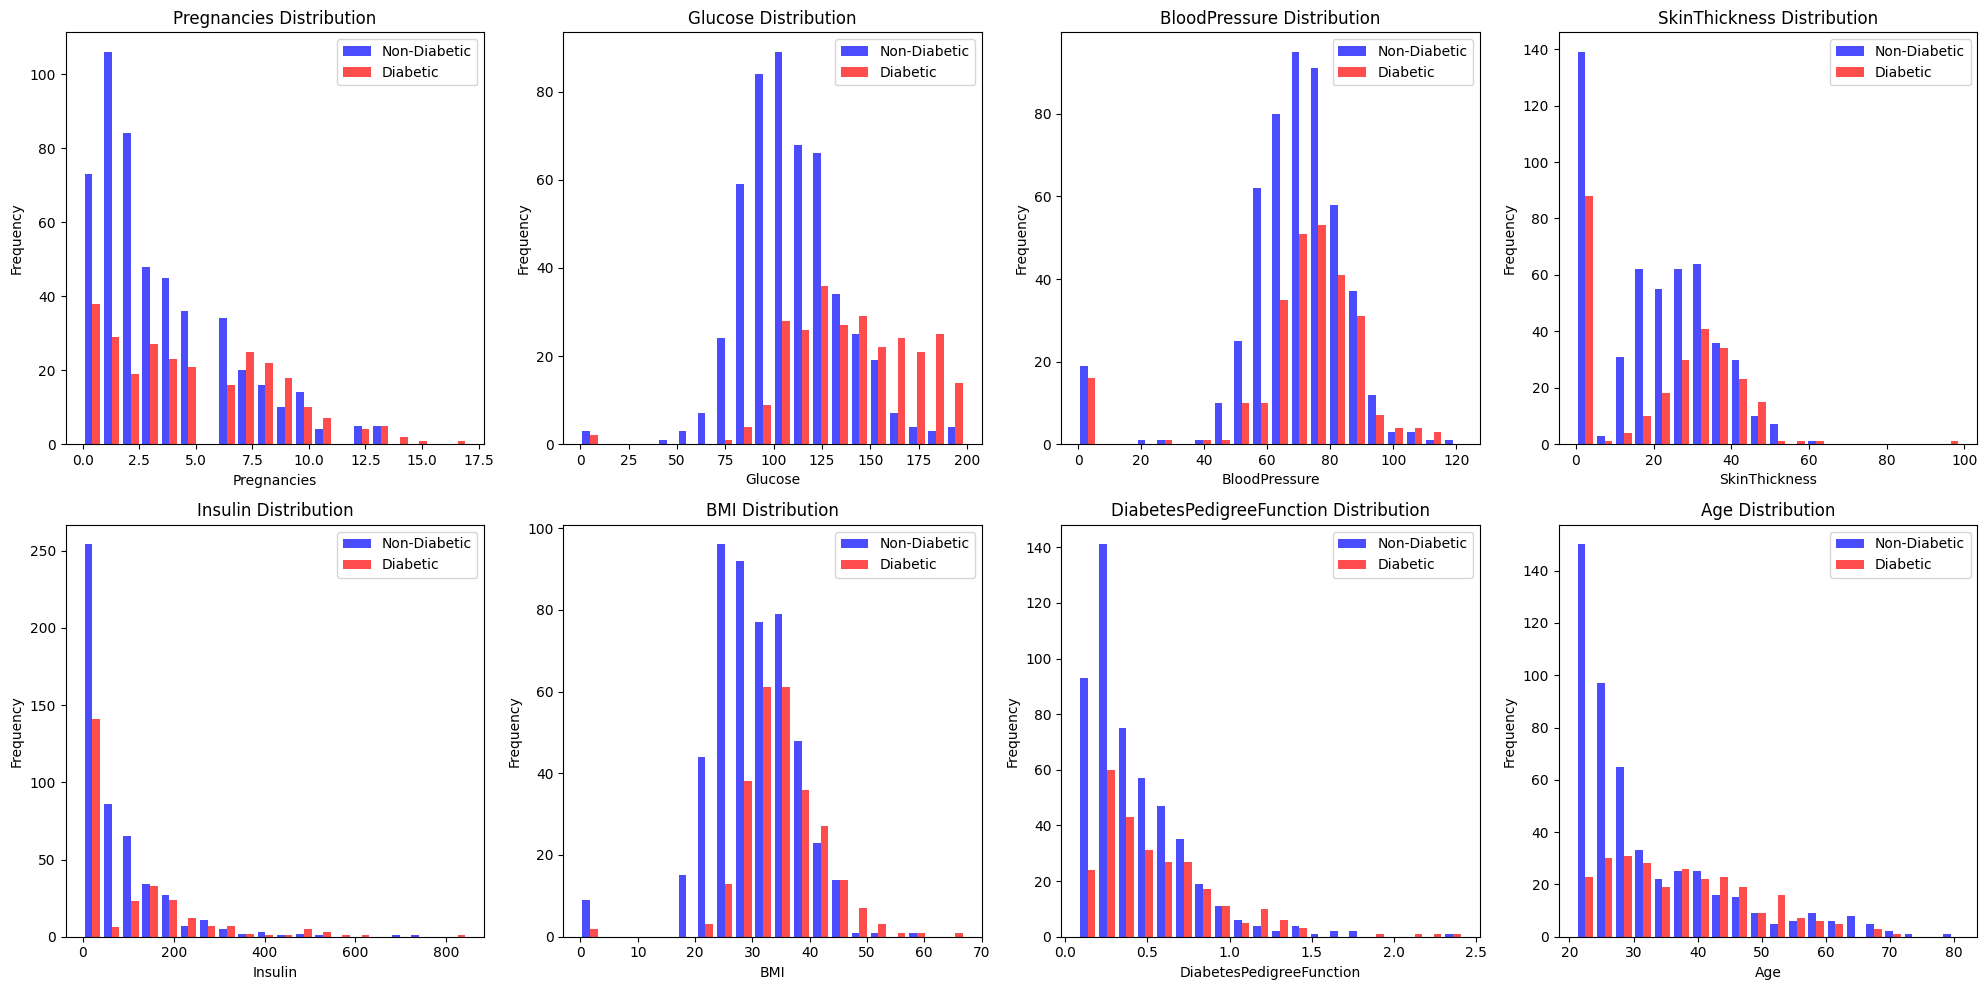

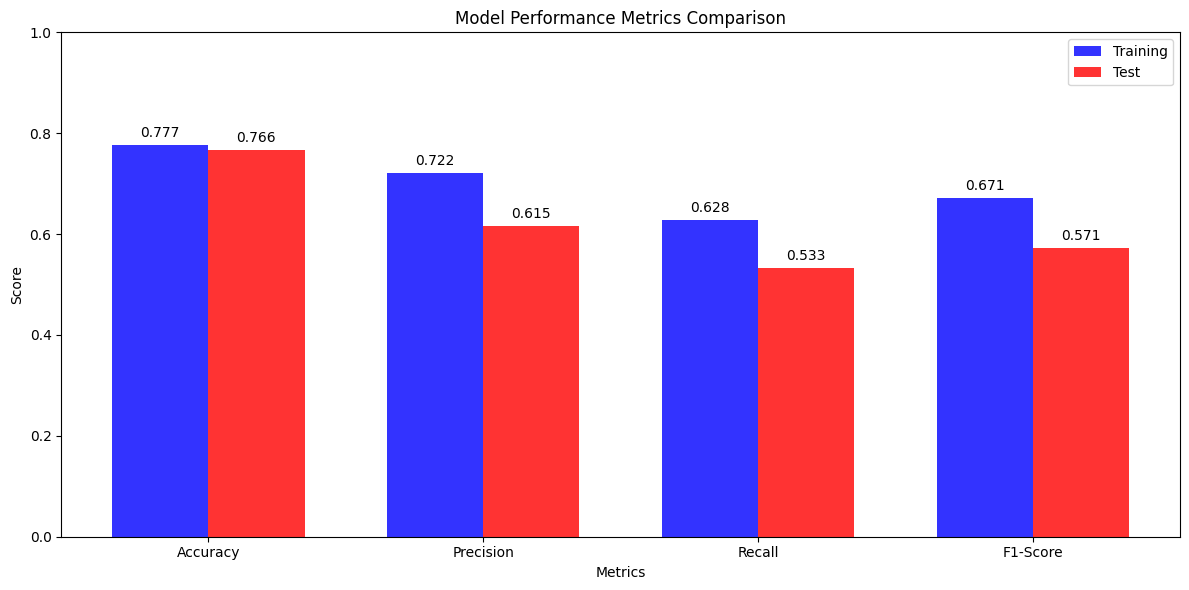

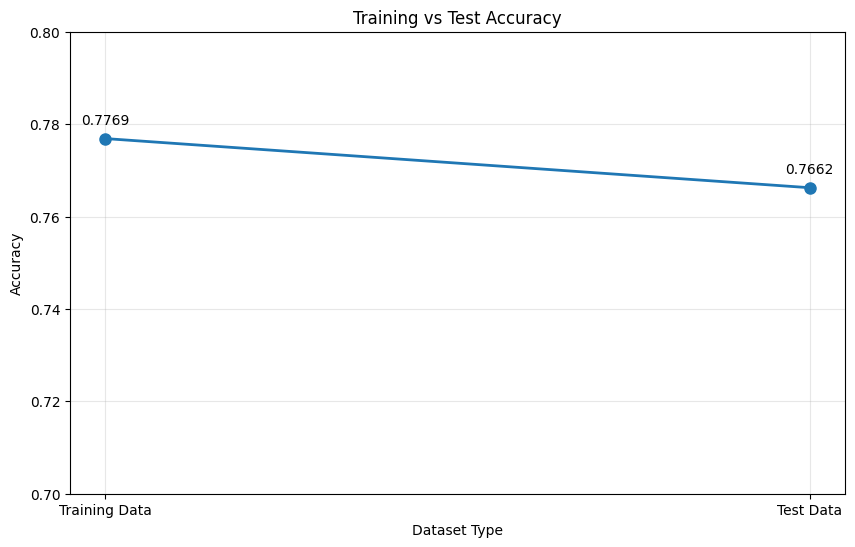

In [261]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

# Create a comprehensive set of visualizations for the logistic regression model

# 1. Confusion Matrix

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Training data confusion matrix
cm_train = confusion_matrix(Y_train, X_train_prediction)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Training Data Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Test data confusion matrix
cm_test = confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Test Data Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# Feature importance visualization (weights)
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
weights = classifer.w
ax3.barh(feature_names, weights, color='skyblue')
ax3.set_title('Feature Weights (Importance)')
ax3.set_xlabel('Weight Value')

# Prediction distribution comparison
ax4.hist([Y_train, X_train_prediction], bins=[0, 0.5, 1, 1.5], alpha=0.7, 
         label=['Actual', 'Predicted'], color=['orange', 'blue'])
ax4.set_title('Training Data: Actual vs Predicted Distribution')
ax4.set_xlabel('Class (0=Non-Diabetic, 1=Diabetic)')
ax4.set_ylabel('Count')
ax4.legend()
ax4.set_xticks([0, 1])

plt.tight_layout()
plt.show()

# 2. ROC Curve and AUC

# Get prediction probabilities for ROC curve
Z_train = X_train.dot(classifer.w) + classifer.b
Y_train_proba = 1 / (1 + np.exp(-Z_train))

Z_test = X_test.dot(classifer.w) + classifer.b
Y_test_proba = 1 / (1 + np.exp(-Z_test))

fpr_train, tpr_train, _ = roc_curve(Y_train, Y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(Y_test, Y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='blue', lw=2, 
         label=f'Training ROC (AUC = {roc_auc_train:.2f})')
plt.plot(fpr_test, tpr_test, color='red', lw=2, 
         label=f'Test ROC (AUC = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 3. Feature correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = diabetes_dataset.drop('Outcome', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# 4. Distribution of features by outcome
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(feature_names):
    diabetic = diabetes_dataset[diabetes_dataset['Outcome'] == 1][feature]
    non_diabetic = diabetes_dataset[diabetes_dataset['Outcome'] == 0][feature]
    
    axes[i].hist([non_diabetic, diabetic], bins=20, alpha=0.7, 
                label=['Non-Diabetic', 'Diabetic'], color=['blue', 'red'])
    axes[i].set_title(f'{feature} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

# 5. Model performance metrics visualization

# Calculate metrics for both training and test data
train_precision = precision_score(Y_train, X_train_prediction)
train_recall = recall_score(Y_train, X_train_prediction)
train_f1 = f1_score(Y_train, X_train_prediction)

test_precision = precision_score(Y_test, X_test_prediction)
test_recall = recall_score(Y_test, X_test_prediction)
test_f1 = f1_score(Y_test, X_test_prediction)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_scores = [training_data_accuracy, train_precision, train_recall, train_f1]
test_scores = [test_data_accuracy, test_precision, test_recall, test_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_scores, width, label='Training', alpha=0.8, color='blue')
plt.bar(x + width/2, test_scores, width, label='Test', alpha=0.8, color='red')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Metrics Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1)

# Add value labels on bars
for i, (train_val, test_val) in enumerate(zip(train_scores, test_scores)):
    plt.text(i - width/2, train_val + 0.01, f'{train_val:.3f}', 
             ha='center', va='bottom')
    plt.text(i + width/2, test_val + 0.01, f'{test_val:.3f}', 
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 6. Learning curve simulation (if we had stored cost function values)
plt.figure(figsize=(10, 6))
plt.plot(range(len(accuracies)), accuracies, 'o-', linewidth=2, markersize=8)
plt.title('Training vs Test Accuracy')
plt.xlabel('Dataset Type')
plt.ylabel('Accuracy')
plt.xticks(range(len(labels)), labels)
plt.grid(True, alpha=0.3)
plt.ylim(0.7, 0.8)
for i, acc in enumerate(accuracies):
    plt.annotate(f'{acc:.4f}', (i, acc), textcoords="offset points", 
                xytext=(0,10), ha='center')
plt.show()

### Creating a Predictive System

In [262]:
input_data = (1,85,66,29,0,26.6,0.351,31)

# Changing the input_data into numpy array

input_data_as_numpy_array = np.asarray(input_data)

# Reshape the array as we are predicting for one instance

input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# Standardize the Input

std_data = scalar.transform(input_data_reshaped)

d:\# My Learning\Coding\Machine-Learning-Tutorial\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [263]:
print(std_data)

[[-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]]


In [264]:
prediciton = classifer.Predict(std_data)
print(prediciton)

[0]


In [265]:
if prediciton[0] == 0:
    print("The Person is Not Diabetic")

else:
    print("The person is Diabetic")

The Person is Not Diabetic
